# Deduplication Experiment Analysis: Experiment 1 vs Experiment 2

This notebook analyzes the effect of SimHash-based data deduplication on model performance across two experiments:
- **Experiment 1**: aiXcoder-7B embeddings
- **Experiment 2**: DeepSeek-Coder-6.7B embeddings

Both experiments compare in-distribution (test) vs out-of-distribution (OOD) generalization across 20 random seeds.

**Key Question**: Does aggressive deduplication improve generalization to external datasets? How do different embeddings affect the results?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load Experiment 1 and Experiment 2 results
exp1_df = pd.read_csv('results/experiment1/results_summary.csv')
exp2_df = pd.read_csv('results/experiment2/results_summary.csv')

# Dataset statistics (same for both experiments)
dataset_stats = {
    'k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'total_samples': [22030, 16684, 12671, 9086, 6495, 4490, 3041, 2000, 1335, 926, 648, 429],
    'retention_pct': [100.0, 75.7, 57.5, 41.2, 29.5, 20.4, 13.8, 9.1, 6.1, 4.2, 2.9, 1.9],
}
df_stats = pd.DataFrame(dataset_stats)

# Merge with dataset stats
exp1_df = pd.merge(exp1_df, df_stats, on='k')
exp2_df = pd.merge(exp2_df, df_stats, on='k')

print("✓ Experiment 1 Results (aiXcoder-7B embeddings):")
print(f"  K values: {exp1_df['k'].tolist()}")
print(f"  Data retention range: {exp1_df['retention_pct'].min():.1f}% - {exp1_df['retention_pct'].max():.1f}%")
print(f"  Seeds: 20")
print()
print("✓ Experiment 2 Results (DeepSeek-Coder-6.7B embeddings):")
print(f"  K values: {exp2_df['k'].tolist()}")
print(f"  Data retention range: {exp2_df['retention_pct'].min():.1f}% - {exp2_df['retention_pct'].max():.1f}%")
print(f"  Seeds: 20")
print()
print("✓ Both datasets loaded successfully!")

NameError: name 'matplotlib' is not defined

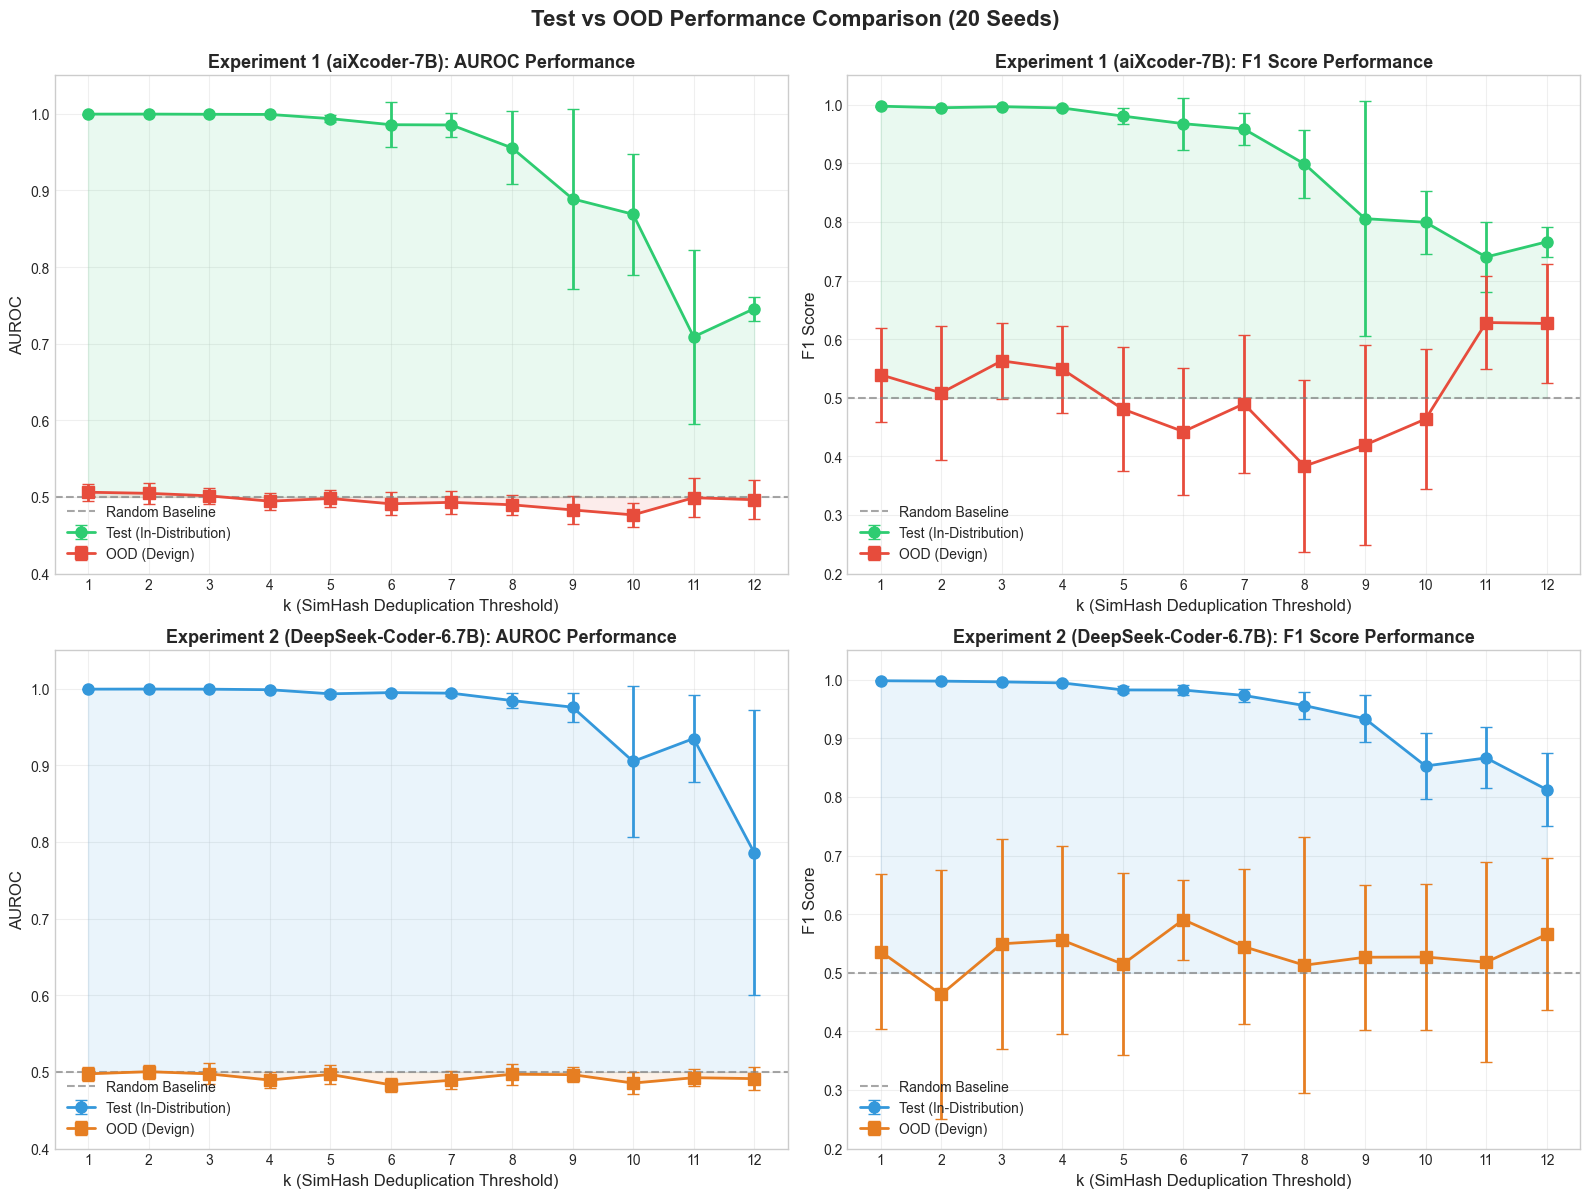


📊 Key Observation: Both experiments show high test performance but OOD performance near random chance (~0.5)


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============ EXPERIMENT 1 ============
# Plot 1: Experiment 1 AUROC
ax1 = axes[0, 0]
ax1.errorbar(exp1_df['k'], exp1_df['test_auroc_mean'], yerr=exp1_df['test_auroc_std'], 
             marker='o', markersize=8, capsize=4, linewidth=2, label='Test (In-Distribution)', color='#2ecc71')
ax1.errorbar(exp1_df['k'], exp1_df['ood_auroc_mean'], yerr=exp1_df['ood_auroc_std'], 
             marker='s', markersize=8, capsize=4, linewidth=2, label='OOD (Devign)', color='#e74c3c')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Baseline')
ax1.fill_between(exp1_df['k'], 0.5, exp1_df['test_auroc_mean'], alpha=0.1, color='#2ecc71')
ax1.fill_between(exp1_df['k'], 0.5, exp1_df['ood_auroc_mean'], alpha=0.1, color='#e74c3c')

ax1.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax1.set_ylabel('AUROC', fontsize=12)
ax1.set_title('Experiment 1 (aiXcoder-7B): AUROC Performance', fontsize=13, fontweight='bold')
ax1.set_xticks(exp1_df['k'])
ax1.set_ylim(0.4, 1.05)
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Experiment 1 F1
ax2 = axes[0, 1]
ax2.errorbar(exp1_df['k'], exp1_df['test_f1_mean'], yerr=exp1_df['test_f1_std'], 
             marker='o', markersize=8, capsize=4, linewidth=2, label='Test (In-Distribution)', color='#2ecc71')
ax2.errorbar(exp1_df['k'], exp1_df['ood_f1_mean'], yerr=exp1_df['ood_f1_std'], 
             marker='s', markersize=8, capsize=4, linewidth=2, label='OOD (Devign)', color='#e74c3c')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Baseline')
ax2.fill_between(exp1_df['k'], 0.5, exp1_df['test_f1_mean'], alpha=0.1, color='#2ecc71')

ax2.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Experiment 1 (aiXcoder-7B): F1 Score Performance', fontsize=13, fontweight='bold')
ax2.set_xticks(exp1_df['k'])
ax2.set_ylim(0.2, 1.05)
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)

# ============ EXPERIMENT 2 ============
# Plot 3: Experiment 2 AUROC
ax3 = axes[1, 0]
ax3.errorbar(exp2_df['k'], exp2_df['test_auroc_mean'], yerr=exp2_df['test_auroc_std'], 
             marker='o', markersize=8, capsize=4, linewidth=2, label='Test (In-Distribution)', color='#3498db')
ax3.errorbar(exp2_df['k'], exp2_df['ood_auroc_mean'], yerr=exp2_df['ood_auroc_std'], 
             marker='s', markersize=8, capsize=4, linewidth=2, label='OOD (Devign)', color='#e67e22')
ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Baseline')
ax3.fill_between(exp2_df['k'], 0.5, exp2_df['test_auroc_mean'], alpha=0.1, color='#3498db')
ax3.fill_between(exp2_df['k'], 0.5, exp2_df['ood_auroc_mean'], alpha=0.1, color='#e67e22')

ax3.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax3.set_ylabel('AUROC', fontsize=12)
ax3.set_title('Experiment 2 (DeepSeek-Coder-6.7B): AUROC Performance', fontsize=13, fontweight='bold')
ax3.set_xticks(exp2_df['k'])
ax3.set_ylim(0.4, 1.05)
ax3.legend(loc='lower left', fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Experiment 2 F1
ax4 = axes[1, 1]
ax4.errorbar(exp2_df['k'], exp2_df['test_f1_mean'], yerr=exp2_df['test_f1_std'], 
             marker='o', markersize=8, capsize=4, linewidth=2, label='Test (In-Distribution)', color='#3498db')
ax4.errorbar(exp2_df['k'], exp2_df['ood_f1_mean'], yerr=exp2_df['ood_f1_std'], 
             marker='s', markersize=8, capsize=4, linewidth=2, label='OOD (Devign)', color='#e67e22')
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Baseline')
ax4.fill_between(exp2_df['k'], 0.5, exp2_df['test_f1_mean'], alpha=0.1, color='#3498db')

ax4.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax4.set_ylabel('F1 Score', fontsize=12)
ax4.set_title('Experiment 2 (DeepSeek-Coder-6.7B): F1 Score Performance', fontsize=13, fontweight='bold')
ax4.set_xticks(exp2_df['k'])
ax4.set_ylim(0.2, 1.05)
ax4.legend(loc='lower left', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.suptitle('Test vs OOD Performance Comparison (20 Seeds)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('exp_comparison_test_vs_ood.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key Observation: Both experiments show high test performance but OOD performance near random chance (~0.5)")

In [ ]:
# Calculate generalization gaps
exp1_df['auroc_gap'] = exp1_df['test_auroc_mean'] - exp1_df['ood_auroc_mean']
exp1_df['f1_gap'] = exp1_df['test_f1_mean'] - exp1_df['ood_f1_mean']

exp2_df['auroc_gap'] = exp2_df['test_auroc_mean'] - exp2_df['ood_auroc_mean']
exp2_df['f1_gap'] = exp2_df['test_f1_mean'] - exp2_df['ood_f1_mean']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============ EXPERIMENT 1 ============
# Plot 1: Exp1 Generalization Gap
ax1 = axes[0, 0]
scatter1 = ax1.scatter(exp1_df['retention_pct'], exp1_df['auroc_gap'], c=exp1_df['k'], cmap='viridis', 
                       s=150, edgecolors='black', linewidth=1.5, zorder=3)
ax1.plot(exp1_df['retention_pct'], exp1_df['auroc_gap'], '--', alpha=0.5, color='gray', zorder=1)

for idx, row in exp1_df.iterrows():
    ax1.annotate(f'k={int(row["k"])}', (row['retention_pct'], row['auroc_gap']), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

ax1.set_xlabel('Data Retention (%)', fontsize=12)
ax1.set_ylabel('AUROC Gap (Test - OOD)', fontsize=12)
ax1.set_title('Exp 1 (aiXcoder): Generalization Gap vs Data Retention', fontsize=13, fontweight='bold')
ax1.axhline(y=0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Perfect Generalization')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('k value', fontsize=10)

# Plot 2: Exp1 Performance vs Dataset Size
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()

line1, = ax2.plot(exp1_df['k'], exp1_df['test_auroc_mean'], 'o-', color='#2ecc71', markersize=8, 
                  linewidth=2, label='Test AUROC')
line2, = ax2.plot(exp1_df['k'], exp1_df['ood_auroc_mean'], 's-', color='#e74c3c', markersize=8, 
                  linewidth=2, label='OOD AUROC')
bars = ax2_twin.bar(exp1_df['k'], exp1_df['total_samples'], alpha=0.3, color='steelblue', label='Dataset Size')

ax2.set_xlabel('k (SimHash Threshold)', fontsize=12)
ax2.set_ylabel('AUROC', fontsize=12, color='black')
ax2_twin.set_ylabel('Dataset Size (samples)', fontsize=12, color='steelblue')
ax2.set_title('Exp 1 (aiXcoder): Performance vs Dataset Size', fontsize=13, fontweight='bold')
ax2.set_xticks(exp1_df['k'])
ax2.set_ylim(0.4, 1.05)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

# ============ EXPERIMENT 2 ============
# Plot 3: Exp2 Generalization Gap
ax3 = axes[1, 0]
scatter2 = ax3.scatter(exp2_df['retention_pct'], exp2_df['auroc_gap'], c=exp2_df['k'], cmap='plasma', 
                       s=150, edgecolors='black', linewidth=1.5, zorder=3)
ax3.plot(exp2_df['retention_pct'], exp2_df['auroc_gap'], '--', alpha=0.5, color='gray', zorder=1)

for idx, row in exp2_df.iterrows():
    ax3.annotate(f'k={int(row["k"])}', (row['retention_pct'], row['auroc_gap']), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

ax3.set_xlabel('Data Retention (%)', fontsize=12)
ax3.set_ylabel('AUROC Gap (Test - OOD)', fontsize=12)
ax3.set_title('Exp 2 (DeepSeek): Generalization Gap vs Data Retention', fontsize=13, fontweight='bold')
ax3.axhline(y=0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Perfect Generalization')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)

cbar2 = plt.colorbar(scatter2, ax=ax3)
cbar2.set_label('k value', fontsize=10)

# Plot 4: Exp2 Performance vs Dataset Size
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

line3, = ax4.plot(exp2_df['k'], exp2_df['test_auroc_mean'], 'o-', color='#3498db', markersize=8, 
                  linewidth=2, label='Test AUROC')
line4, = ax4.plot(exp2_df['k'], exp2_df['ood_auroc_mean'], 's-', color='#e67e22', markersize=8, 
                  linewidth=2, label='OOD AUROC')
bars2 = ax4_twin.bar(exp2_df['k'], exp2_df['total_samples'], alpha=0.3, color='coral', label='Dataset Size')

ax4.set_xlabel('k (SimHash Threshold)', fontsize=12)
ax4.set_ylabel('AUROC', fontsize=12, color='black')
ax4_twin.set_ylabel('Dataset Size (samples)', fontsize=12, color='coral')
ax4.set_title('Exp 2 (DeepSeek): Performance vs Dataset Size', fontsize=13, fontweight='bold')
ax4.set_xticks(exp2_df['k'])
ax4.set_ylim(0.4, 1.05)
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

lines2 = [line3, line4]
labels2 = [l.get_label() for l in lines2]
ax4.legend(lines2, labels2, loc='lower left', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle('Generalization Gap Analysis (20 Seeds)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('exp_comparison_generalization_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 Experiment 1 Generalization Gap Range: {exp1_df['auroc_gap'].min():.3f} - {exp1_df['auroc_gap'].max():.3f}")
print(f"? Experiment 2 Generalization Gap Range: {exp2_df['auroc_gap'].min():.3f} - {exp2_df['auroc_gap'].max():.3f}")
print(f"\n?📉 Exp1: Even at k=12 (98% removed), OOD AUROC = {exp1_df[exp1_df['k']==12]['ood_auroc_mean'].values[0]:.3f}")
print(f"📉 Exp2: Even at k=12 (98% removed), OOD AUROC = {exp2_df[exp2_df['k']==12]['ood_auroc_mean'].values[0]:.3f}")

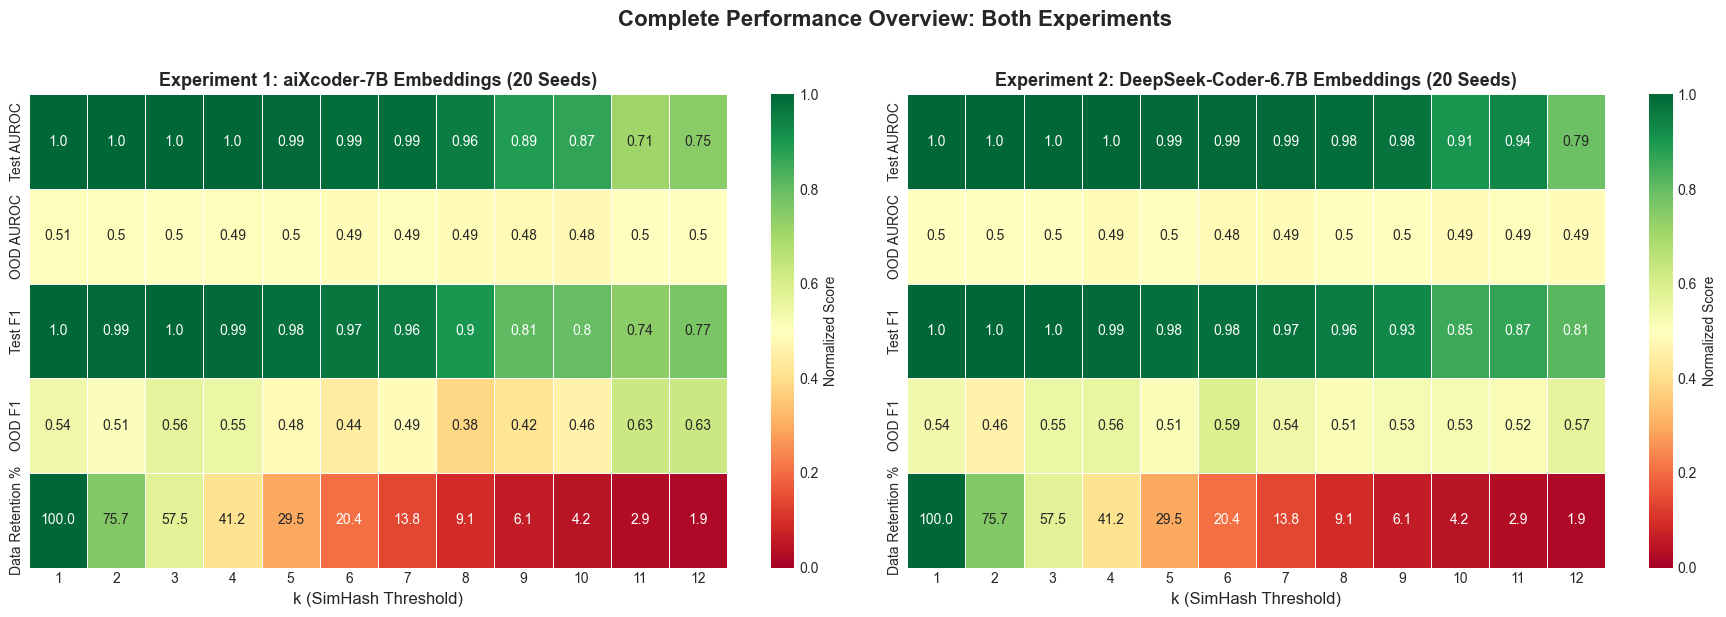

In [3]:
# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Experiment 1 Heatmap
heatmap_data1 = exp1_df[['k', 'test_auroc_mean', 'ood_auroc_mean', 'test_f1_mean', 'ood_f1_mean', 'retention_pct']].copy()
heatmap_data1 = heatmap_data1.set_index('k').T
heatmap_data1.index = ['Test AUROC', 'OOD AUROC', 'Test F1', 'OOD F1', 'Data Retention %']

heatmap_normalized1 = heatmap_data1.copy()
heatmap_normalized1.loc['Data Retention %'] = heatmap_normalized1.loc['Data Retention %'] / 100

sns.heatmap(heatmap_normalized1, annot=heatmap_data1.round(2), fmt='', cmap='RdYlGn', 
            linewidths=0.5, ax=axes[0], vmin=0, vmax=1, cbar_kws={'label': 'Normalized Score'})
axes[0].set_xlabel('k (SimHash Threshold)', fontsize=12)
axes[0].set_title('Experiment 1: aiXcoder-7B Embeddings (20 Seeds)', fontsize=13, fontweight='bold')

# Experiment 2 Heatmap
heatmap_data2 = exp2_df[['k', 'test_auroc_mean', 'ood_auroc_mean', 'test_f1_mean', 'ood_f1_mean', 'retention_pct']].copy()
heatmap_data2 = heatmap_data2.set_index('k').T
heatmap_data2.index = ['Test AUROC', 'OOD AUROC', 'Test F1', 'OOD F1', 'Data Retention %']

heatmap_normalized2 = heatmap_data2.copy()
heatmap_normalized2.loc['Data Retention %'] = heatmap_normalized2.loc['Data Retention %'] / 100

sns.heatmap(heatmap_normalized2, annot=heatmap_data2.round(2), fmt='', cmap='RdYlGn', 
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Normalized Score'})
axes[1].set_xlabel('k (SimHash Threshold)', fontsize=12)
axes[1].set_title('Experiment 2: DeepSeek-Coder-6.7B Embeddings (20 Seeds)', fontsize=13, fontweight='bold')

plt.suptitle('Complete Performance Overview: Both Experiments', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp_comparison_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 'auroc_gap'

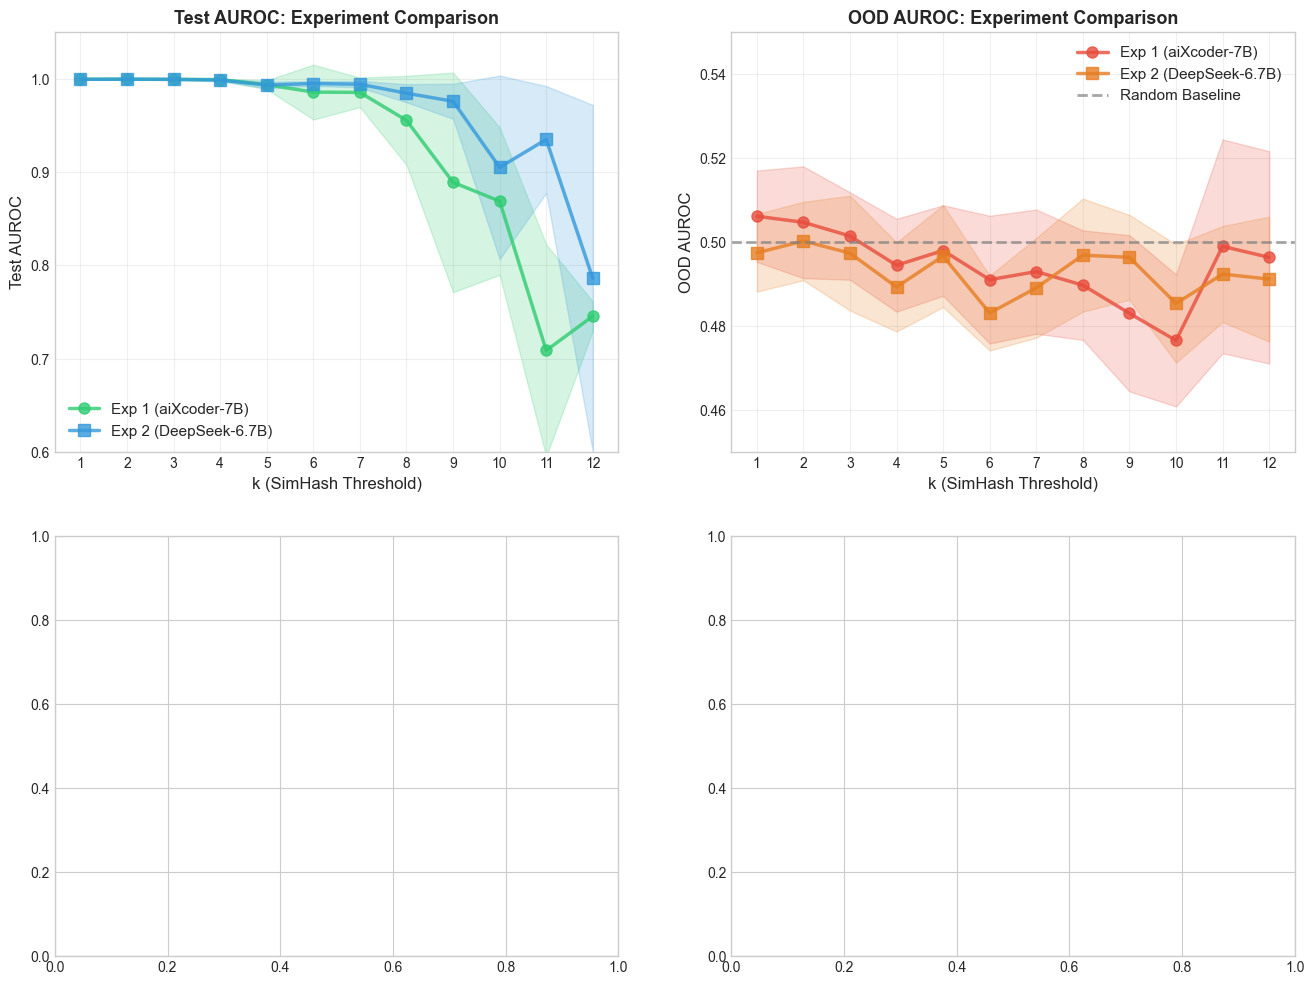

In [4]:
# Direct comparison: Experiment 1 vs Experiment 2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test AUROC Comparison
ax1 = axes[0, 0]
ax1.plot(exp1_df['k'], exp1_df['test_auroc_mean'], 'o-', color='#2ecc71', markersize=8, 
         linewidth=2.5, label='Exp 1 (aiXcoder-7B)', alpha=0.8)
ax1.fill_between(exp1_df['k'], 
                 exp1_df['test_auroc_mean'] - exp1_df['test_auroc_std'],
                 exp1_df['test_auroc_mean'] + exp1_df['test_auroc_std'],
                 alpha=0.2, color='#2ecc71')

ax1.plot(exp2_df['k'], exp2_df['test_auroc_mean'], 's-', color='#3498db', markersize=8, 
         linewidth=2.5, label='Exp 2 (DeepSeek-6.7B)', alpha=0.8)
ax1.fill_between(exp2_df['k'], 
                 exp2_df['test_auroc_mean'] - exp2_df['test_auroc_std'],
                 exp2_df['test_auroc_mean'] + exp2_df['test_auroc_std'],
                 alpha=0.2, color='#3498db')

ax1.set_xlabel('k (SimHash Threshold)', fontsize=12)
ax1.set_ylabel('Test AUROC', fontsize=12)
ax1.set_title('Test AUROC: Experiment Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(exp1_df['k'])
ax1.set_ylim(0.6, 1.05)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: OOD AUROC Comparison
ax2 = axes[0, 1]
ax2.plot(exp1_df['k'], exp1_df['ood_auroc_mean'], 'o-', color='#e74c3c', markersize=8, 
         linewidth=2.5, label='Exp 1 (aiXcoder-7B)', alpha=0.8)
ax2.fill_between(exp1_df['k'], 
                 exp1_df['ood_auroc_mean'] - exp1_df['ood_auroc_std'],
                 exp1_df['ood_auroc_mean'] + exp1_df['ood_auroc_std'],
                 alpha=0.2, color='#e74c3c')

ax2.plot(exp2_df['k'], exp2_df['ood_auroc_mean'], 's-', color='#e67e22', markersize=8, 
         linewidth=2.5, label='Exp 2 (DeepSeek-6.7B)', alpha=0.8)
ax2.fill_between(exp2_df['k'], 
                 exp2_df['ood_auroc_mean'] - exp2_df['ood_auroc_std'],
                 exp2_df['ood_auroc_mean'] + exp2_df['ood_auroc_std'],
                 alpha=0.2, color='#e67e22')

ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Random Baseline')
ax2.set_xlabel('k (SimHash Threshold)', fontsize=12)
ax2.set_ylabel('OOD AUROC', fontsize=12)
ax2.set_title('OOD AUROC: Experiment Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(exp1_df['k'])
ax2.set_ylim(0.45, 0.55)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Generalization Gap Comparison
ax3 = axes[1, 0]
ax3.plot(exp1_df['k'], exp1_df['auroc_gap'], 'o-', color='#9b59b6', markersize=8, 
         linewidth=2.5, label='Exp 1 (aiXcoder-7B)', alpha=0.8)
ax3.plot(exp2_df['k'], exp2_df['auroc_gap'], 's-', color='#f39c12', markersize=8, 
         linewidth=2.5, label='Exp 2 (DeepSeek-6.7B)', alpha=0.8)
ax3.axhline(y=0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Perfect Generalization')

ax3.set_xlabel('k (SimHash Threshold)', fontsize=12)
ax3.set_ylabel('AUROC Gap (Test - OOD)', fontsize=12)
ax3.set_title('Generalization Gap: Experiment Comparison', fontsize=13, fontweight='bold')
ax3.set_xticks(exp1_df['k'])
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Plot 4: Standard Deviation Comparison (Stability)
ax4 = axes[1, 1]
width = 0.35
x = np.arange(len(exp1_df['k']))

bars1 = ax4.bar(x - width/2, exp1_df['test_auroc_std'], width, label='Exp 1 (aiXcoder-7B)', 
                color='#2ecc71', alpha=0.7)
bars2 = ax4.bar(x + width/2, exp2_df['test_auroc_std'], width, label='Exp 2 (DeepSeek-6.7B)', 
                color='#3498db', alpha=0.7)

ax4.set_xlabel('k (SimHash Threshold)', fontsize=12)
ax4.set_ylabel('Test AUROC Std Dev', fontsize=12)
ax4.set_title('Model Stability Across Seeds (Lower = Better)', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(exp1_df['k'])
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Direct Comparison: Experiment 1 vs Experiment 2 (20 Seeds Each)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('exp_direct_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"Best Test AUROC (Exp 1): {exp1_df['test_auroc_mean'].max():.4f} at k={exp1_df.loc[exp1_df['test_auroc_mean'].idxmax(), 'k']}")
print(f"Best Test AUROC (Exp 2): {exp2_df['test_auroc_mean'].max():.4f} at k={exp2_df.loc[exp2_df['test_auroc_mean'].idxmax(), 'k']}")
print()
print(f"Best OOD AUROC (Exp 1): {exp1_df['ood_auroc_mean'].max():.4f} at k={exp1_df.loc[exp1_df['ood_auroc_mean'].idxmax(), 'k']}")
print(f"Best OOD AUROC (Exp 2): {exp2_df['ood_auroc_mean'].max():.4f} at k={exp2_df.loc[exp2_df['ood_auroc_mean'].idxmax(), 'k']}")
print()
print(f"Smallest Gap (Exp 1): {exp1_df['auroc_gap'].min():.4f} at k={exp1_df.loc[exp1_df['auroc_gap'].idxmin(), 'k']}")
print(f"Smallest Gap (Exp 2): {exp2_df['auroc_gap'].min():.4f} at k={exp2_df.loc[exp2_df['auroc_gap'].idxmin(), 'k']}")
print("="*60)

In [5]:
# Summary statistics table
summary_stats = {
    'Metric': [
        'Mean Test AUROC',
        'Mean OOD AUROC',
        'Mean Generalization Gap',
        'Best Test AUROC',
        'Best OOD AUROC',
        'Worst Generalization Gap',
        'Mean Test Std Dev',
        'Mean OOD Std Dev',
    ],
    'Experiment 1 (aiXcoder-7B)': [
        f"{exp1_df['test_auroc_mean'].mean():.4f}",
        f"{exp1_df['ood_auroc_mean'].mean():.4f}",
        f"{exp1_df['auroc_gap'].mean():.4f}",
        f"{exp1_df['test_auroc_mean'].max():.4f}",
        f"{exp1_df['ood_auroc_mean'].max():.4f}",
        f"{exp1_df['auroc_gap'].max():.4f}",
        f"{exp1_df['test_auroc_std'].mean():.4f}",
        f"{exp1_df['ood_auroc_std'].mean():.4f}",
    ],
    'Experiment 2 (DeepSeek-6.7B)': [
        f"{exp2_df['test_auroc_mean'].mean():.4f}",
        f"{exp2_df['ood_auroc_mean'].mean():.4f}",
        f"{exp2_df['auroc_gap'].mean():.4f}",
        f"{exp2_df['test_auroc_mean'].max():.4f}",
        f"{exp2_df['ood_auroc_mean'].max():.4f}",
        f"{exp2_df['auroc_gap'].max():.4f}",
        f"{exp2_df['test_auroc_std'].mean():.4f}",
        f"{exp2_df['ood_auroc_std'].mean():.4f}",
    ]
}

summary_df = pd.DataFrame(summary_stats)

print("\n" + "="*80)
print("COMPREHENSIVE EXPERIMENT COMPARISON (Averaged over 20 Seeds)")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Create styled table visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                cellLoc='center', loc='center', 
                colWidths=[0.4, 0.3, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color header
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#2C3E50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_df) + 1):
    for j in range(len(summary_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ECF0F1')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')

plt.title('Summary Statistics: Experiment 1 vs Experiment 2', fontsize=14, fontweight='bold', pad=20)
plt.savefig('exp_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 'auroc_gap'